<a href="https://colab.research.google.com/github/llferda/colab-projects/blob/main/XGBoost_Powered_Churn_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df=pd.read_csv("ecommerce_customer_churn_dataset.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [ ]:
df.isnull().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Eksik verileri doldurma
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

# Kategorik değişkenleri sayısallaştırma (Label Encoding)
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
# Hedef (y) ve Özellikler (X)
X = df.drop('Churned', axis=1)
y = df['Churned']

# Eğitim ve test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Sınıflandırıcı
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic', # İkili sınıflandırma için
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

print("Doğruluk Payı (Accuracy):", accuracy_score(y_test, y_pred))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

Doğruluk Payı (Accuracy): 0.9215

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7130
           1       0.93      0.79      0.85      2870

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.90     10000
weighted avg       0.92      0.92      0.92     10000



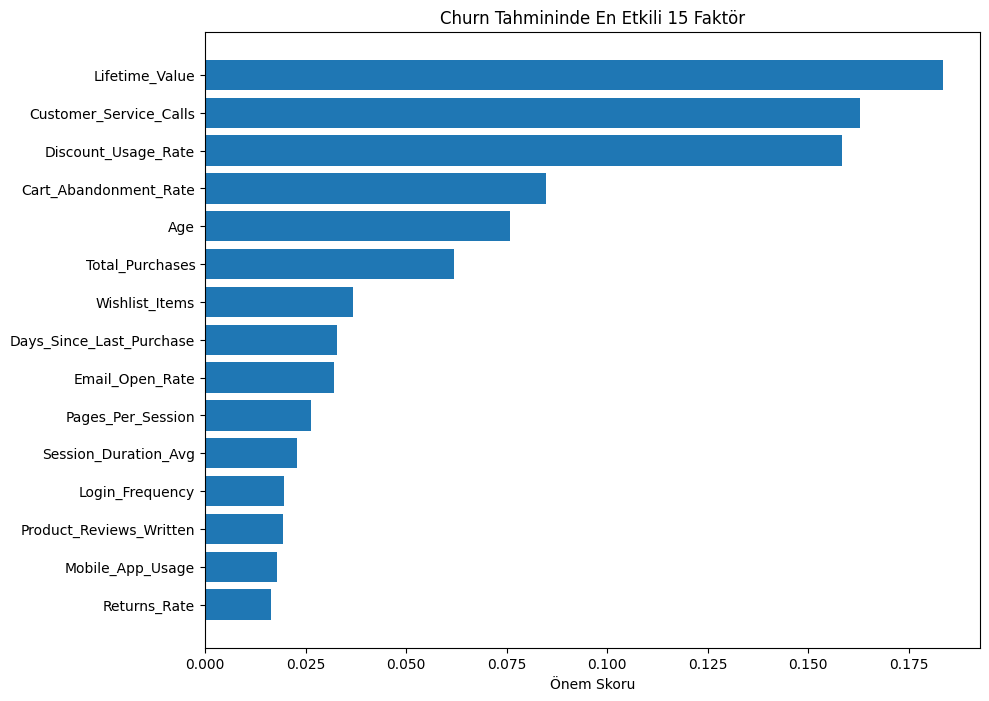

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Özellik önem düzeylerini alalım
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Görselleştirelim
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'][:15], importances['importance'][:15])
plt.xlabel('Önem Skoru')
plt.title('Churn Tahmininde En Etkili 15 Faktör')
plt.gca().invert_yaxis()
plt.show()

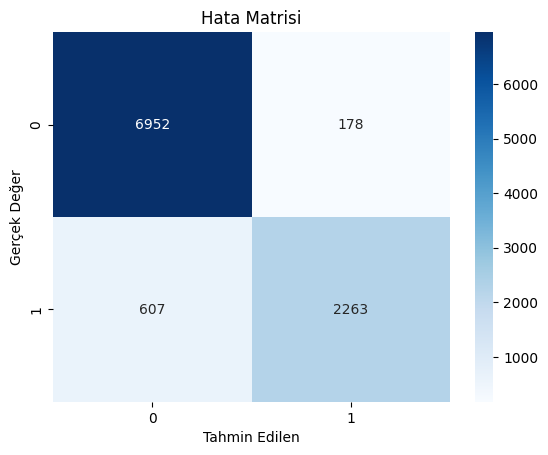

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Hata Matrisi')
plt.show()

In [ ]:
# Müşterilerin ayrılma olasılıklarını (olasılık değerlerini) alalım
y_probs = model.predict_proba(X_test)[:, 1] # 1 olma olasılığı

# Test setindeki verilerle olasılıkları birleştirelim
risk_listesi = X_test.copy()
risk_listesi['Churn_Olasiligi'] = y_probs
risk_listesi['Gercek_Durum'] = y_test.values

# En riskli 10 müşteriyi görelim
print(risk_listesi.sort_values(by='Churn_Olasiligi', ascending=False).head(10))

        Age  Gender  Country  City  Membership_Years  Login_Frequency  \
15978  18.0       0        6    16               2.7             10.0   
16912  21.0       1        7    18               3.3              8.0   
36056  18.0       0        1    38               1.1             16.0   
20525  21.0       0        7    13               0.2             21.0   
17688  18.0       0        7    13               3.9             19.0   
9097   23.0       0        4     1               4.7             14.0   
9549   18.0       0        7    18               5.8             28.0   
5348   18.0       0        7    33               4.4             12.0   
46734  18.0       0        7    27               5.9             12.0   
34709  18.0       0        7     7               0.2             16.0   

       Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
15978                  37.1               12.5                   44.1   
16912                  23.3                9.9    

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

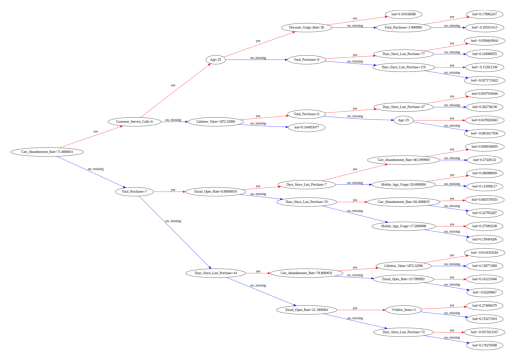

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Modeldeki ilk ağacı (index 0) çizdirelim
plt.figure(figsize=(20,10))
xgb.plot_tree(model, num_trees=0, rankdir='LR') # LR: Soldan sağa akış
plt.show()

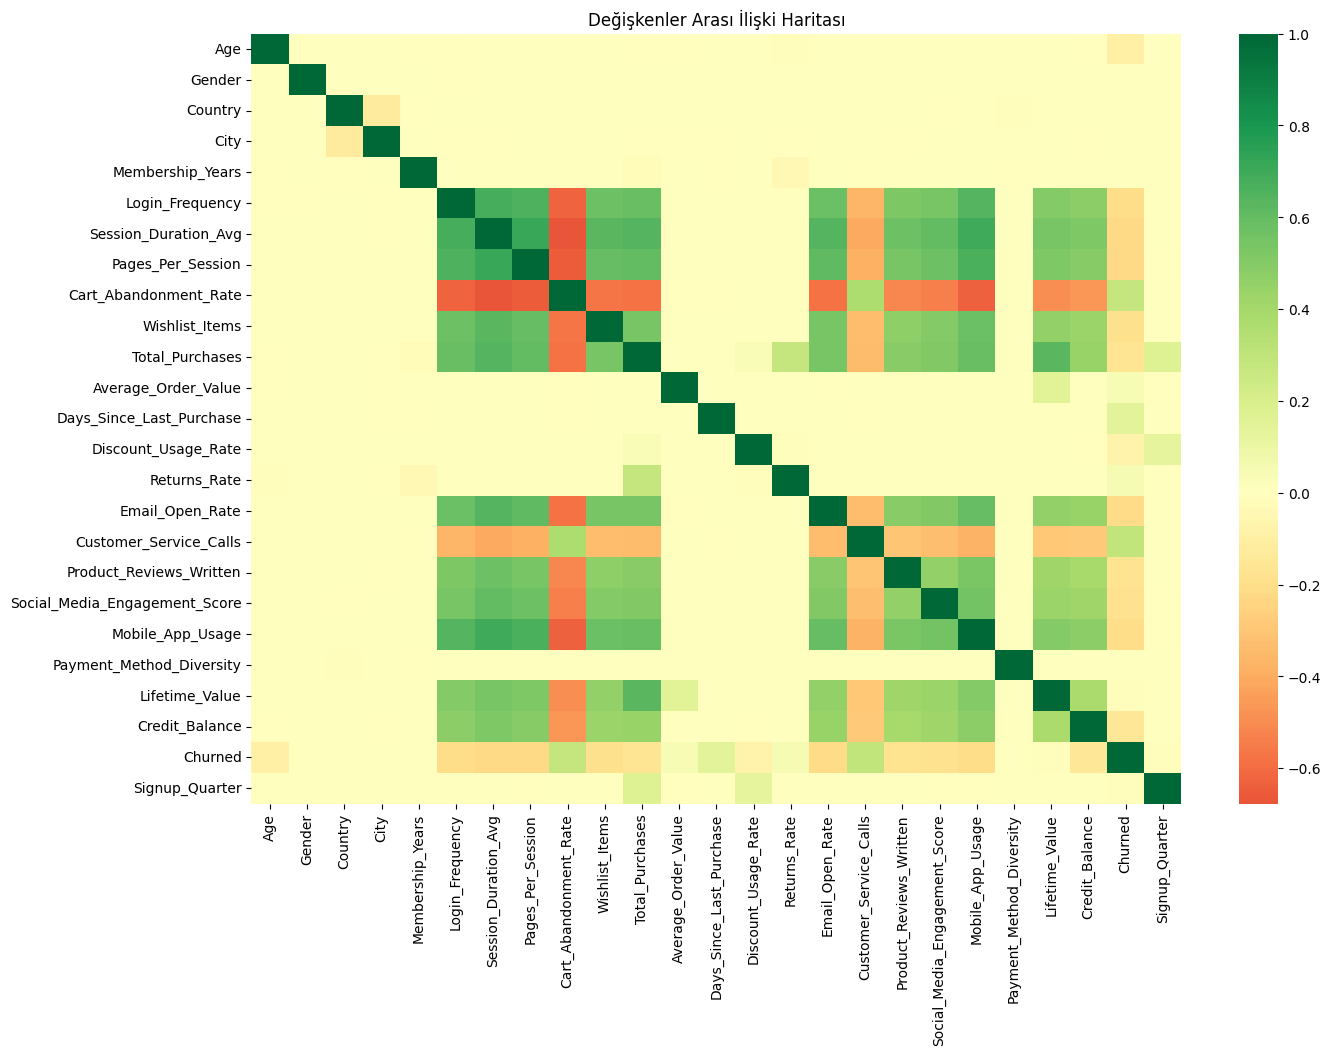

In [ ]:
import seaborn as sns

# Sadece sayısal sütunları seçip korelasyon matrisi oluşturalım
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='RdYlGn', center=0)
plt.title("Değişkenler Arası İlişki Haritası")
plt.show()

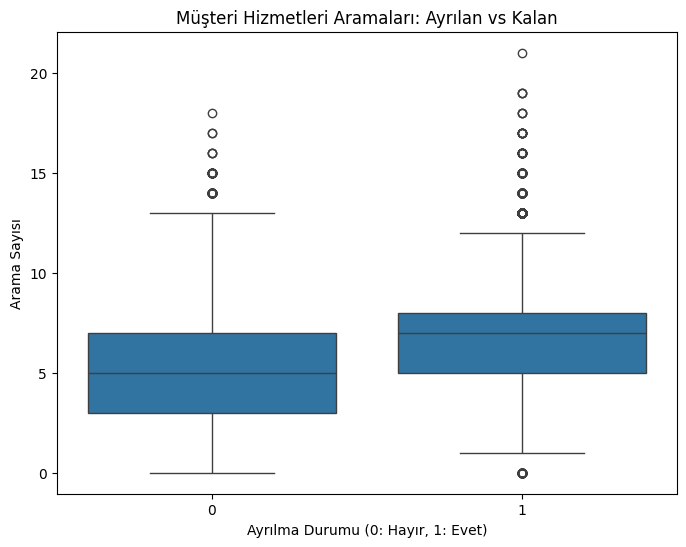

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df)
plt.title("Müşteri Hizmetleri Aramaları: Ayrılan vs Kalan")
plt.xlabel("Ayrılma Durumu (0: Hayır, 1: Evet)")
plt.ylabel("Arama Sayısı")
plt.show()

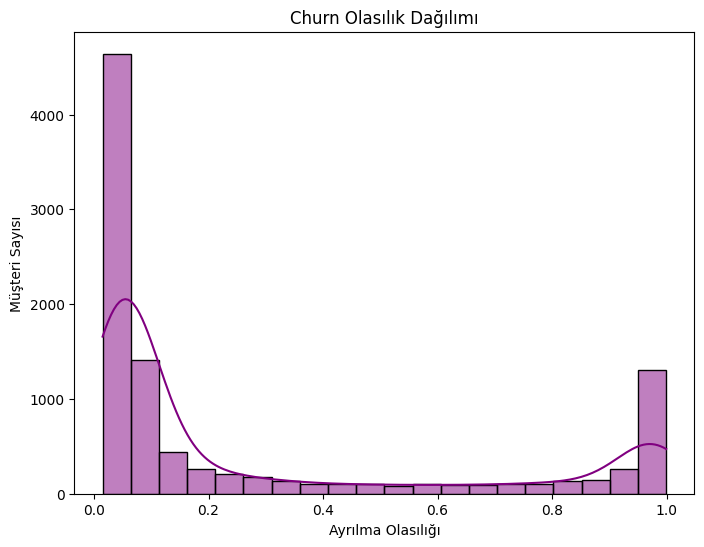

In [ ]:
y_probs = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(8, 6))
sns.histplot(y_probs, bins=20, kde=True, color='purple')
plt.title("Churn Olasılık Dağılımı")
plt.xlabel("Ayrılma Olasılığı")
plt.ylabel("Müşteri Sayısı")
plt.show()

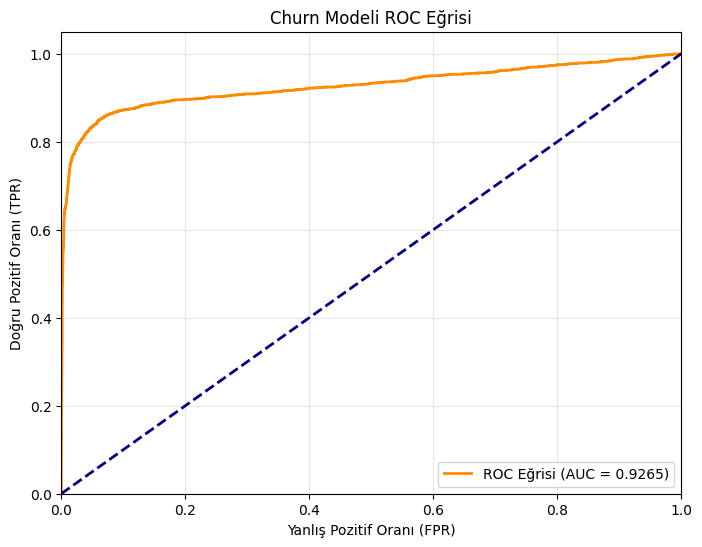

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Olasılıkları alalım (Daha önce almıştık ama garanti olsun)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. ROC eğrisi için değerleri hesaplayalım
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Görselleştirme
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('Churn Modeli ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipython-input-2000398491.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df, palette='Set2')


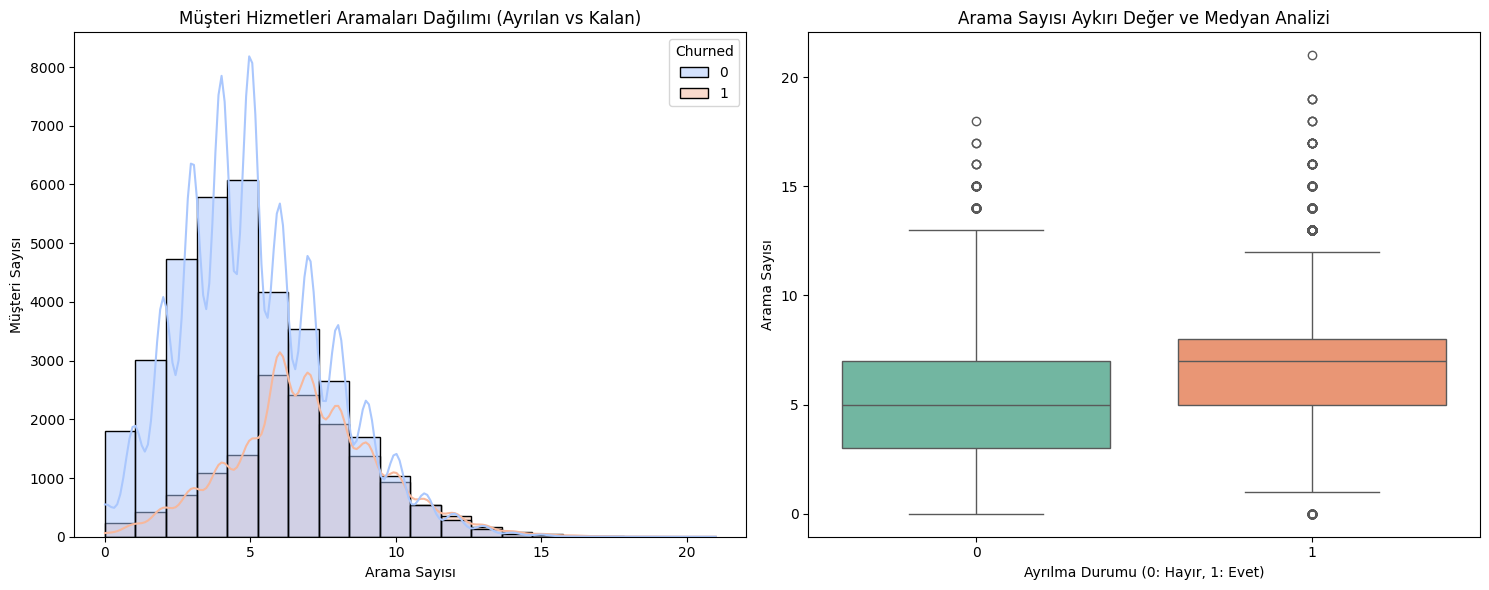

In [ ]:
#şikayet sayısı arttıkça müşteri bizi gerçekten bırakıyor mu?" sorusunun somut kanıtını görmüş olacağız.
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme boyutlarını ayarlayalım
plt.figure(figsize=(15,6))

# 1. Grafik: Dağılım (Histogram)
plt.subplot(1,2,1)
sns.histplot(x='Customer_Service_Calls',
             hue='Churned',
             data=df, # Veri seti adın df ise bu şekilde güncelledim
             bins=20, # 40 yerine 20-30 arası daha net bir görünüm verebilir
             kde=True,
             palette='coolwarm')
plt.title('Müşteri Hizmetleri Aramaları Dağılımı (Ayrılan vs Kalan)')
plt.xlabel('Arama Sayısı')
plt.ylabel('Müşteri Sayısı')

# 2. Grafik: Kutu Grafiği (Boxplot)
plt.subplot(1,2,2)
sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df, palette='Set2')
plt.title('Arama Sayısı Aykırı Değer ve Medyan Analizi')
plt.xlabel('Ayrılma Durumu (0: Hayır, 1: Evet)')
plt.ylabel('Arama Sayısı')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

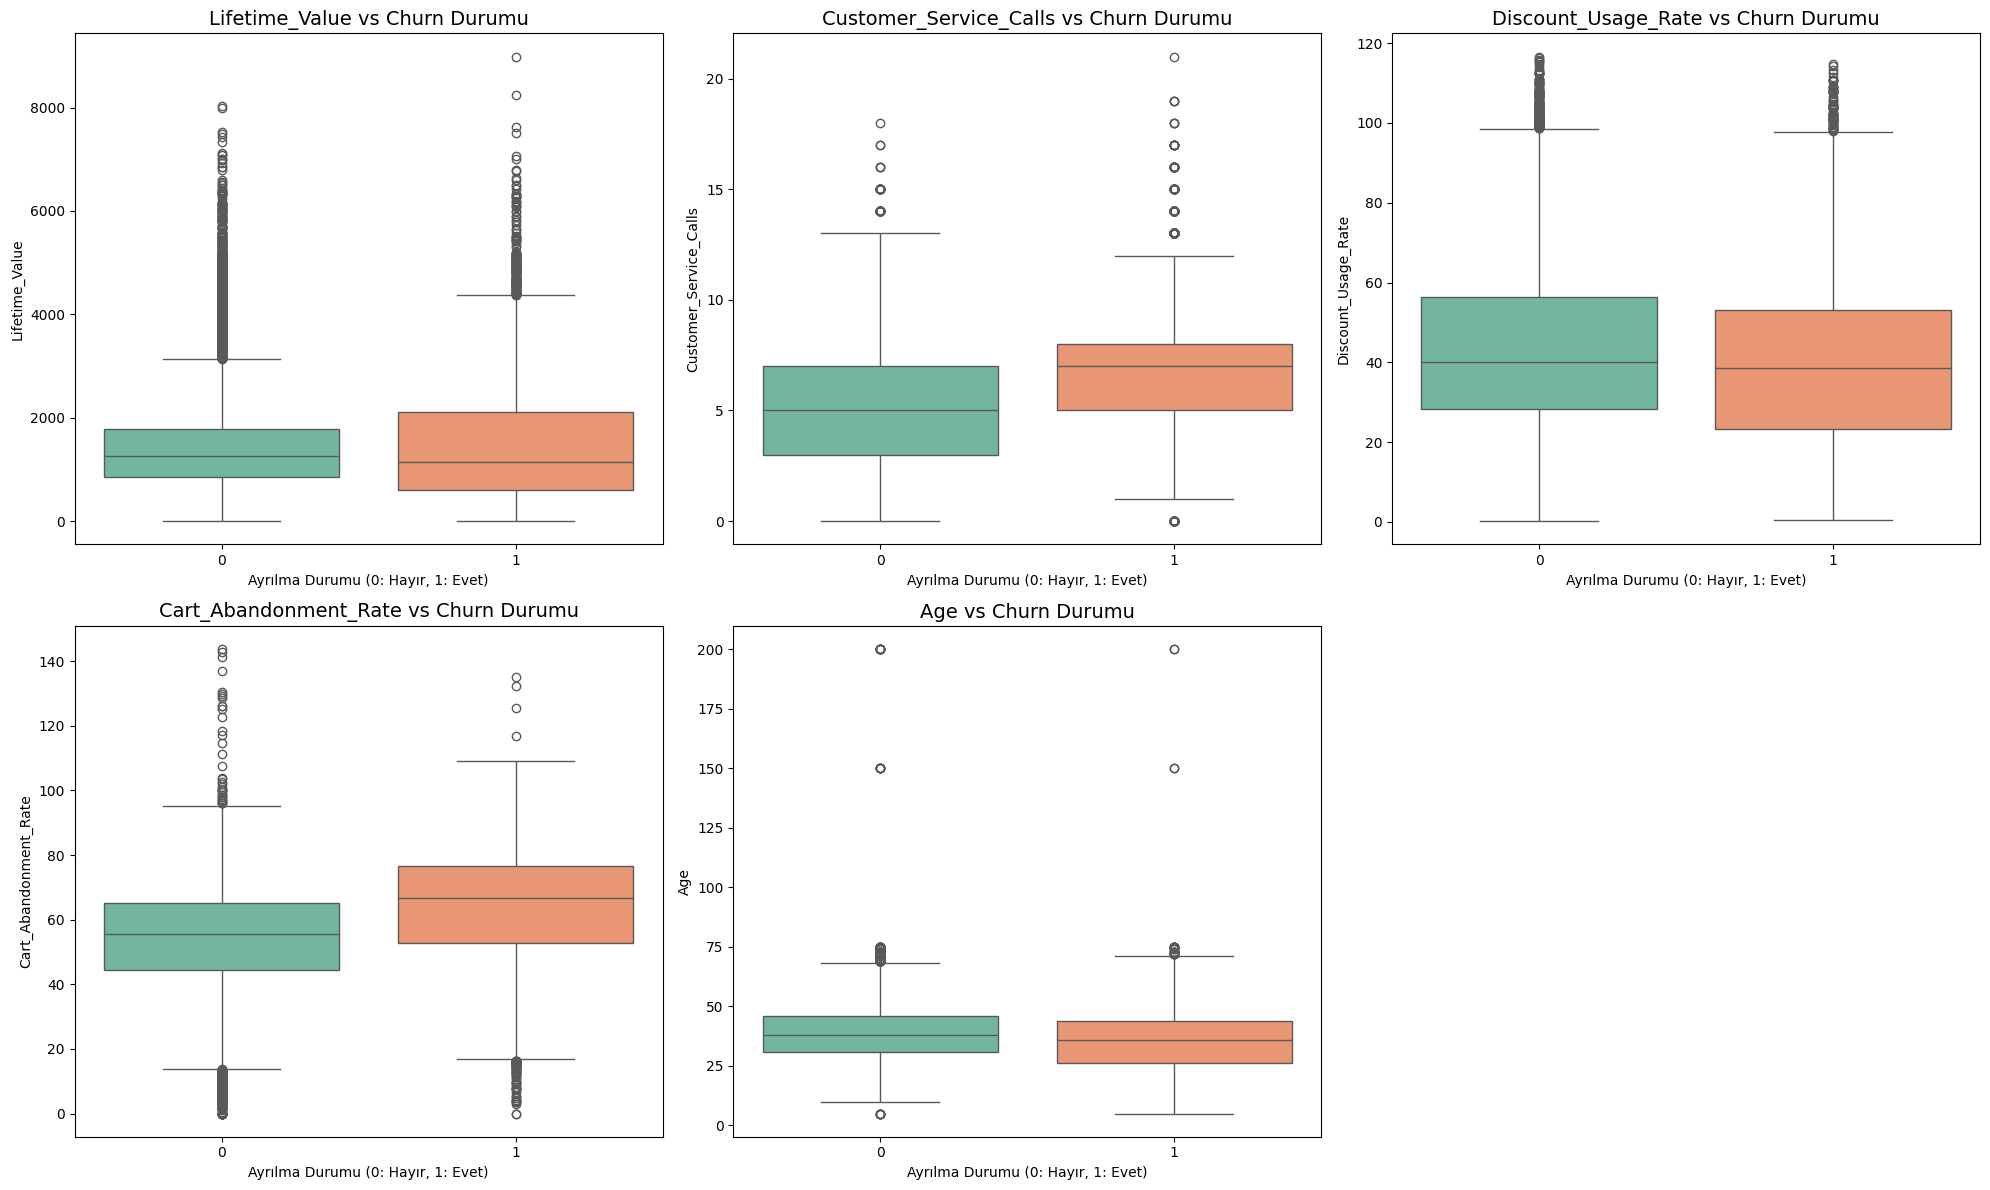

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# En etkili 5 değişkeni listeleyelim
top_5_features = ['Lifetime_Value', 'Customer_Service_Calls', 'Discount_Usage_Rate', 'Cart_Abandonment_Rate', 'Age']

plt.figure(figsize=(20, 12))

for i, col in enumerate(top_5_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Churn Durumu', fontsize=14)
    plt.xlabel('Ayrılma Durumu (0: Hayır, 1: Evet)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2793145539.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churned'] == 0][col], label='Kalanlar', shade=True, color="blue")
/tmp/ipython-input-2793145539.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churned'] == 1][col], label='Ayrılanlar', shade=True, color="red")
/tmp/ipython-input-2793145539.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churned'] == 0][col], label='Kalanlar', shade=True, color="blue")
/tmp/ipython-input-2793145539.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error i

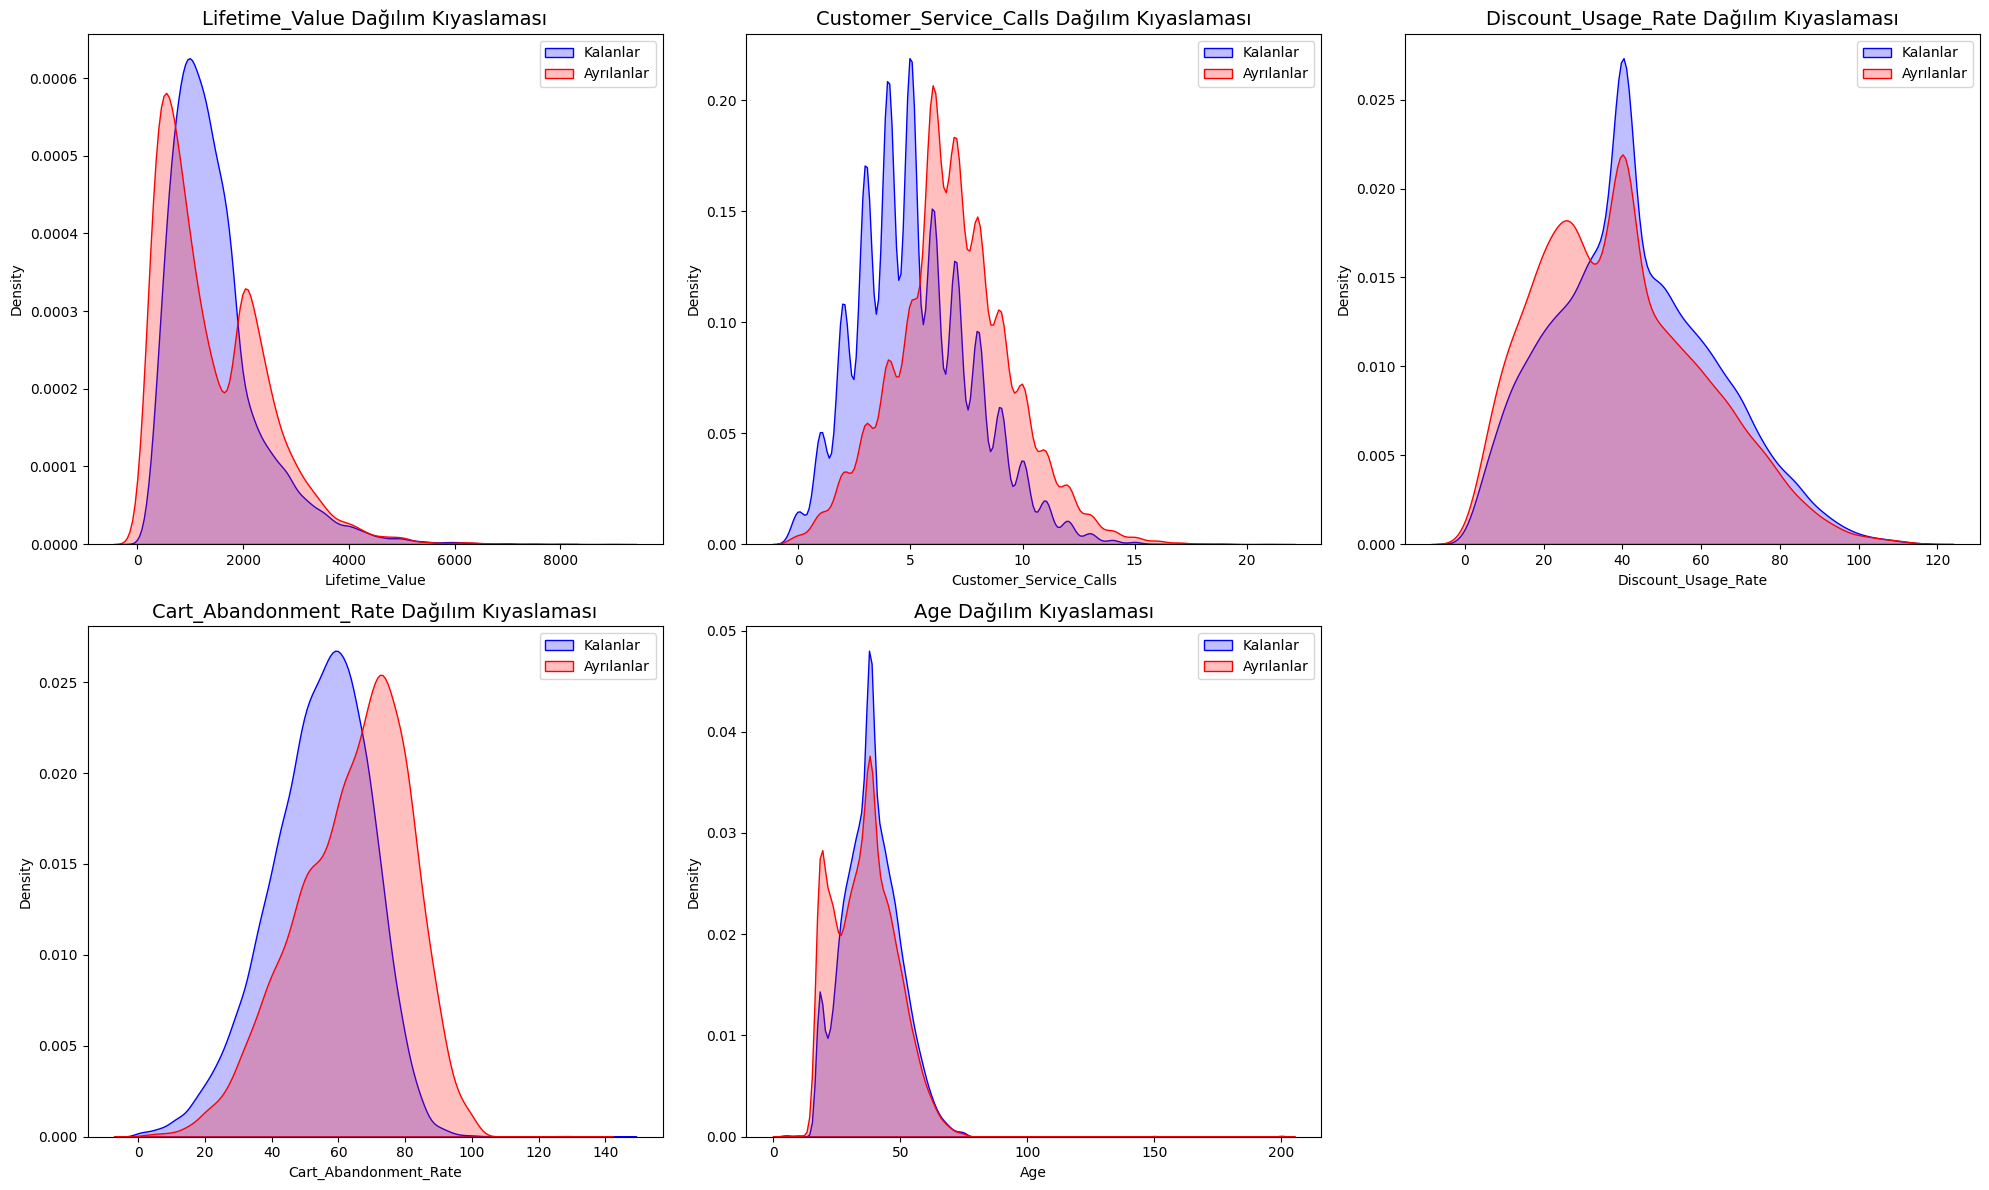

In [ ]:
#Yoğunluk ve Eşik Değer Analizi (KDE Plots)
plt.figure(figsize=(20, 12))

for i, col in enumerate(top_5_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df[df['Churned'] == 0][col], label='Kalanlar', shade=True, color="blue")
    sns.kdeplot(data=df[df['Churned'] == 1][col], label='Ayrılanlar', shade=True, color="red")
    plt.title(f'{col} Dağılım Kıyaslaması', fontsize=14)
    plt.legend()

plt.tight_layout()
plt.show()